# Pillar 4 — Optimization: Why Plain Gradient Descent Struggles
## Demo 1: The Learning-Rate Problem

Same loss curve `L(w) = w²`, same starting point, three different learning rates.
This shows why hand-picking the learning rate (η) is fragile:
- **too small** → crawls, wastes time
- **just right** → smooth, fast descent
- **too big** → overshoots and diverges (loss explodes → "NaN" in real training)

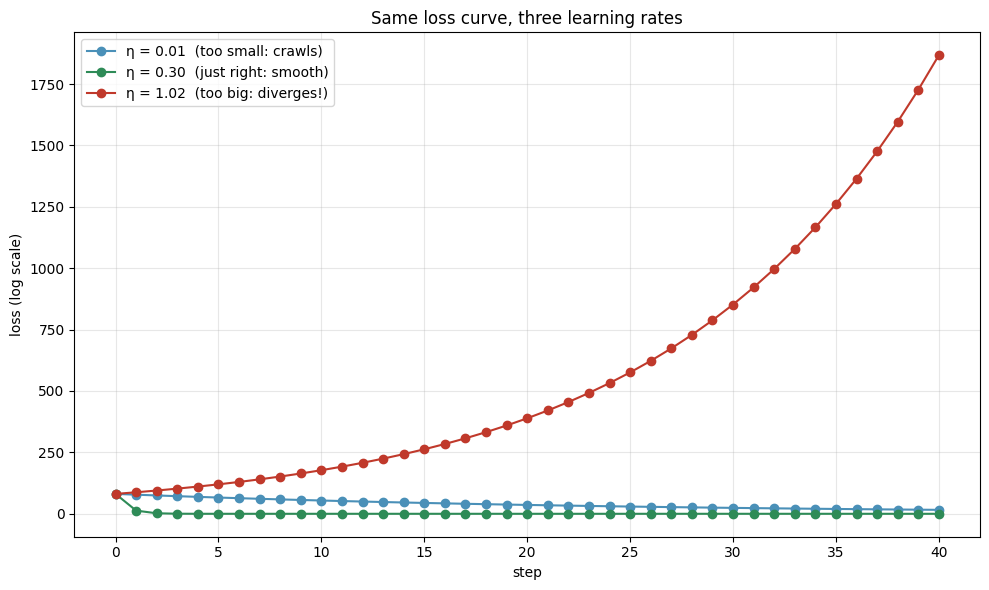

LOSS at selected steps (start loss = 81):
 step                                                                  too_small(0.01)  just_right(0.30)     too_big(1.02)
    0           81.0000         81.000000             81.00
    5           66.1829          0.008493            119.90
   10           54.0762          0.000001            177.48
   20           36.1017          0.000000            388.88
   40           16.0906          0.000000           1867.03


In [10]:
import matplotlib.pyplot as plt

def loss(w):
    return w**2

def gradient(w):
    return 2*w


def run_gd(learningRate,steps=40,w=9.0):
    history = []
    history.append(loss(w)) 
    for _ in range(steps): 
       w = w -learningRate * gradient(w)
       history.append(loss(w)) 
    return history    
        

too_small  = run_gd(0.01)   # crawls
just_right = run_gd(0.30)   # smooth descent
too_big    = run_gd(1.02)   # overshoots and diverges


plt.figure(figsize=(10,6))
plt.plot(too_small,  'o-', label='η = 0.01  (too small: crawls)',     color='#4a90b8')
plt.plot(just_right, 'o-', label='η = 0.30  (just right: smooth)',    color='#2e8b57')
plt.plot(too_big,    'o-', label='η = 1.02  (too big: diverges!)',    color='#c0392b')
# plt.yscale('log')                       # log scale so all three fit on one plot
plt.xlabel('step')
plt.ylabel('loss (log scale)')
plt.title('Same loss curve, three learning rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("LOSS at selected steps (start loss = 81):")
print(f"{'step':>5}{'too_small(0.01)':>18}{'just_right(0.30)':>18}{'too_big(1.02)':>18}")
for s in [0, 5, 10, 20, 40]:
    print(f"{s:>5}{too_small[s]:>18.4f}{just_right[s]:>18.6f}{too_big[s]:>18.2f}")
    